In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp


In [ ]:
# --- Global Spacetime Parameters ---
# We use geometrized units (G=c=1)
# M is the mass of the black hole.
M = 1.0

# --- Schwarzschild Helper Functions (Analytic) ---


def get_metric(x):
    """
    Returns the covariant Schwarzschild metric tensor g_{\mu\nu}
    at position x = [t, r, theta, phi].

    Args:
        x (np.array): 4D position vector [t, r, \theta, \phi]

    Returns:
        np.array: 4x4 metric tensor g_{\mu\nu}
    """
    t, r, theta, phi = x

    # Avoid division by zero at r=0 or r=2M
    if r <= 2.0 * M or r <= 3.0 * M:  # Also avoid 3M for velocity
        # A robust simulation would handle this, e.g., by stopping.
        # For this example, we'll return NaN to indicate a problem.
        return np.full((4, 4), np.nan)

    f = 1.0 - 2.0 * M / r

    g = np.zeros((4, 4))
    g[0, 0] = -f
    g[1, 1] = 1.0 / f
    g[2, 2] = r**2
    g[3, 3] = (r * np.sin(theta)) ** 2

    return g


def get_kappa(x):
    """
    Returns the partial derivatives of the metric \partial_\kappa g_{\mu\nu}
    at position x = [t, r, theta, phi].

    Args:
        x (np.array): 4D position vector [t, r, \theta, \phi]

    Returns:
        np.array: 4x4x4 tensor d_g[\kappa, \mu, \nu]
    """
    t, r, theta, phi = x

    d_g = np.zeros((4, 4, 4))

    if r <= 2.0 * M:
        return np.full((4, 4, 4), np.nan)

    f = 1.0 - 2.0 * M / r
    # \partial_r (1 - 2M/r) = 2M/r^2
    f_prime = 2.0 * M / (r**2)

    sin_t = np.sin(theta)
    cos_t = np.cos(theta)

    # --- kappa = 1 (derivatives w.r.t r) ---
    d_g[1, 0, 0] = -f_prime  # \partial_r g_tt
    d_g[1, 1, 1] = -f_prime / (f**2)  # \partial_r g_rr
    d_g[1, 2, 2] = 2.0 * r  # \partial_r g_theta_theta
    d_g[1, 3, 3] = 2.0 * r * (sin_t**2)  # \partial_r g_phi_phi

    # --- kappa = 2 (derivatives w.r.t theta) ---
    # Only g_phi_phi depends on theta
    d_g[2, 3, 3] = 2.0 * (r**2) * sin_t * cos_t  # \partial_theta g_phi_phi

    # kappa = 0 (t) and kappa = 3 (phi) derivatives are all zero

    return d_g


def get_riemann(x):
    """
    Returns the fully covariant Riemann tensor R_{\mu\lambda\nu\sigma}
    at position x = [t, r, theta, phi].

    Args:
        x (np.array): 4D position vector [t, r, \theta, \phi]

    Returns:
        np.array: 4x4x4x4 tensor R[\mu, \lambda, \nu, \sigma]
    """
    t, r, theta, phi = x

    R = np.zeros((4, 4, 4, 4))

    if r <= 2.0 * M:
        return np.full((4, 4, 4, 4), np.nan)

    f = 1.0 - 2.0 * M / r
    sin_t_sq = np.sin(theta) ** 2

    # --- Non-zero components (and their anti-symmetries) ---

    # R_trtr = - R_rttr = - R_trrt = R_rt_rt
    val = -(2.0 * M / r**3) * f
    R[0, 1, 0, 1] = val
    R[1, 0, 0, 1] = -val
    R[0, 1, 1, 0] = -val
    R[1, 0, 1, 0] = val

    # R_t\theta t\theta
    val = (M / r) * f
    R[0, 2, 0, 2] = val
    R[2, 0, 0, 2] = -val
    R[0, 2, 2, 0] = -val
    R[2, 0, 2, 0] = val

    # R_t\phi t\phi
    val = (M / r) * f * sin_t_sq
    R[0, 3, 0, 3] = val
    R[3, 0, 0, 3] = -val
    R[0, 3, 3, 0] = -val
    R[3, 0, 3, 0] = val

    # R_r\theta r\theta
    val = -(M / r) / f
    R[1, 2, 1, 2] = val
    R[2, 1, 1, 2] = -val
    R[1, 2, 2, 1] = -val
    R[2, 1, 2, 1] = val

    # R_r\phi r\phi
    val = -(M / r) * sin_t_sq / f
    R[1, 3, 1, 3] = val
    R[3, 1, 1, 3] = -val
    R[1, 3, 3, 1] = -val
    R[3, 1, 3, 1] = val

    # R_\theta\phi\theta\phi
    val = 2.0 * M * r * sin_t_sq
    R[2, 3, 2, 3] = val
    R[3, 2, 2, 3] = -val
    R[2, 3, 3, 2] = -val
    R[3, 2, 3, 2] = val

    return R


def get_covariant_circular_velocity(r, theta=np.pi / 2.0):
    """
    Calculates the COVARIANT 4-velocity u_\mu for a circular orbit at radius r.

    Returns:
        u_cov (np.array): 4-vector u_\mu = [u_t, u_r, u_theta, u_phi]
    """
    if r <= 3.0 * M:
        return np.full((4,), np.nan)

    # Get contravariant velocity u^\mu
    u_t_con = np.sqrt(1.0 / (1.0 - 3.0 * M / r))
    u_phi_con = np.sqrt(M / r**3) * u_t_con
    u_con = np.array([u_t_con, 0.0, 0.0, u_phi_con])

    # Get metric g_{\mu\nu}
    f = 1.0 - 2.0 * M / r
    g_cov = np.zeros((4, 4))
    g_cov[0, 0] = -f
    g_cov[1, 1] = 1.0 / f
    g_cov[2, 2] = r**2
    g_cov[3, 3] = (r * np.sin(theta)) ** 2

    # Calculate covariant velocity u_\mu = g_{\mu\nu} u^\nu
    u_cov = g_cov @ u_con
    return u_cov

## Using Riccati Equation

In [ ]:

# --- NEW HELPER FUNCTION 2 (Corrected) ---

def calculate_initial_B_matrix(x0):
    """
    Calculates the initial B_{\mu\nu} = \nabla_\nu u_\mu tensor for the
    congruence of stable circular orbits.
    
    Args:
        x0 (np.array): The initial 4-position [t, r, \theta, \phi]
    
    Returns:
        B0 (np.array): The 4x4 initial B_{\mu\nu} tensor
    """
    print("Calculating initial B_{\mu\nu} for stable orbit congruence...")
    
    r0, theta0 = x0[1], x0[2]
    
    # --- 1. Calculate \Gamma^\lambda_{\beta\alpha} u_\lambda ---
    
    # Get metric, inverse, and derivatives at x0
    g_cov = get_metric(x0)
    g_con = np.linalg.inv(g_cov)
    d_g = get_kappa(x0)
    
    # Get covariant velocity u_\lambda at r0
    u_cov = get_covariant_circular_velocity(r0, theta0) # u_\lambda
    
    # Calculate Christoffel symbols \Gamma^\lambda_{\beta\alpha}
    term1 = np.einsum('alb->lab', d_g)
    term2 = np.einsum('bla->lab', d_g)
    term3 = -np.einsum('lab->lab', d_g)
    Gamma = 0.5 * np.einsum('ml,lab->mab', g_con, (term1 + term2 + term3))
    
    # Calculate the Christoffel term: C_{\beta\alpha} = \Gamma^\lambda_{\beta\alpha} u_\lambda
    # Gamma[lam, beta, alpha] * u_cov[lam] -> result[beta, alpha]
    christoffel_term = np.einsum('lba,l->ba', Gamma, u_cov)
    
    # --- 2. Calculate P_{\alpha\beta} = \partial_\beta u_\alpha (Numerical Derivative) ---
    
    # We only need the \beta = 1 (r-derivative) column
    partial_deriv_term = np.zeros((4, 4))
    
    epsilon = 1e-6 * r0 # A small radial step
    
    u_cov_plus = get_covariant_circular_velocity(r0 + epsilon, theta0)
    u_cov_minus = get_covariant_circular_velocity(r0 - epsilon, theta0)
    
    # Calculate \partial_r u_\alpha
    du_dr = (u_cov_plus - u_cov_minus) / (2.0 * epsilon)
    
    # This is the P_{\alpha, \beta=1} column
    partial_deriv_term[:, 1] = du_dr
    
    # --- 3. Combine them: B_{\alpha\beta} = P_{\alpha\beta} - C_{\beta\alpha}
    
    # B_{\alpha\beta} = P_{\alpha\beta} - (C^T)_{\alpha\beta}
    # B0 = partial_deriv_term - christoffel_term.T
    
    # *** THIS IS THE CORRECTED LINE ***
    B0 = partial_deriv_term - christoffel_term.T
    
    print("Initial B_{\mu\nu} calculated.")
    return B0

In [ ]:
def evolve_deformation_tensor(x_initial, u_initial, B_initial, tau_final, num_steps=100, max_step=0.1):
    """
    Evolves a geodesic and its covariant deformation tensor B_{\mu\nu}.
    ... (docstring as before) ...
    """
    
    # *** THIS IS THE UPDATED DERIVATIVES FUNCTION ***
    def derivatives(tau, y):
        """
        Calculates the derivatives dY/d\tau for the ODE solver.
        
        Args:
            tau (float): Current proper time (ignored, system is autonomous)
            y (np.array): Current state vector Y (1D array of 24 elements)
        
        State vector Y layout:
        y[0:4]   = x^\mu (4-position)
        y[4:8]   = u^\mu (4-velocity)
        y[8:24]  = B_{\mu\nu} (16 components, flattened)
        """
        
        # --- 1. Unpack state vector ---
        x = y[0:4]
        u = y[4:8]
        B = y[8:24].reshape(4, 4)
        
        # --- 2. Get spacetime data at current position x ---
        g_cov = get_metric(x)         # g_{\mu\nu}
        d_g = get_kappa(x)            # \partial_\kappa g_{\mu\nu}
        R_cov = get_riemann(x)        # R_{\mu\lambda\nu\sigma}
        
        # Handle coordinate singularity
        if np.isnan(g_cov.any()):
            #print("Error: Geodesic hit singularity.")
            # Return NaN to stop integration
            return np.full(y.shape, np.nan)
            
        g_con = np.linalg.inv(g_cov)  # g^{\mu\nu}

        # --- 3. *** NEW: CONSTRAINT PROJECTION *** ---
        # We analytically know u^r and u^\theta must be 0 for this orbit.
        # We enforce this to prevent numerical error from accumulating.
        u[1] = 0.0 # u^r
        u[2] = 0.0 # u^\theta
        
        # We also know g_{\mu\nu}u^\mu u^\nu = -1. We use this to
        # re-calculate u^t based on u^\phi, cleaning any error.
        # -1 = g_tt * (u^t)^2 + g_\phi\phi * (u^\phi)^2
        # (u^t)^2 = (-1 - g_\phi\phi * (u^\phi)^2) / g_tt
        g_tt = g_cov[0, 0]
        g_pp = g_cov[3, 3]
        u_p = u[3]
        
        # Ensure the argument to sqrt is non-negative to avoid NaN from float errors
        u_t_sq_arg = (-1.0 - g_pp * u_p**2) / g_tt
        u[0] = np.sqrt(max(0, u_t_sq_arg))
        # --- END OF CONSTRAINT PROJECTION ---

        
        # --- 4. Calculate Christoffel symbols \Gamma^\mu_{\alpha\beta} ---
        Gamma = np.zeros((4, 4, 4)) # Gamma[mu, alpha, beta]
        
        # Use einsum for a fast, vectorized calculation
        # \Gamma^\mu_{\alpha\beta} = 1/2 g^{\mu\lambda} (\partial_\alpha g_{\lambda\beta} + \partial_\beta g_{\lambda\alpha} - \partial_\lambda g_{\alpha\beta})
        # d_g[alpha, lam, beta] + d_g[beta, lam, alpha] - d_g[lam, alpha, beta]
        term1 = np.einsum('alb->lab', d_g)
        term2 = np.einsum('bla->lab', d_g)
        term3 = -np.einsum('lab->lab', d_g)
        
        Gamma = 0.5 * np.einsum('ml,lab->mab', g_con, (term1 + term2 + term3))
                        
        # --- 5. Calculate the 24 derivatives ---
        
        # (Eq 1: 4 derivatives) dx^\mu / d\tau = u^\mu
        dx_dt = u
        
        # (Eq 2: 4 derivatives) du^\mu / d\tau = - \Gamma^\mu_{\alpha\beta} u^\alpha u^\beta
        du_dt = -np.einsum('mab,a,b->m', Gamma, u, u)
        
        # (Eq 3: 16 derivatives) dB_{\mu\nu} / d\tau = ...
        
        # Term 1: - B_{\mu\lambda} g^{\lambda\alpha} B_{\alpha\nu}
        Term1 = -B @ g_con @ B
        
        # Term 2: - R_{\mu\lambda\nu\sigma} u^\lambda u^\sigma
        Term2 = -np.einsum('mlns,l,s->mn', R_cov, u, u)
        
        # Term 3: + u^\lambda \Gamma^\sigma_{\lambda\mu} B_{\sigma\nu}
        Term3 = np.einsum('l,slm,sn->mn', u, Gamma, B)
        
        # Term 4: + u^\lambda \Gamma^\sigma_{\lambda\nu} B_{\mu\sigma}
        Term4 = np.einsum('l,sln,ms->mn', u, Gamma, B)
        
        dB_dt_matrix = Term1 + Term2 + Term3 + Term4
        dB_dt = dB_dt_matrix.flatten() # Flatten for the state vector
        
        # --- 6. Combine all 24 derivatives ---
        dY = np.concatenate([dx_dt, du_dt, dB_dt])
        
        return dY

    # --- Set up and run the solver ---
    y0 = np.concatenate([x_initial, u_initial, B_initial.flatten()])
    t_span = (0, tau_final)
    t_eval = np.linspace(t_span[0], t_span[1], num_steps)
    
    print("Starting ODE integration...")
    sol = solve_ivp(
        fun=derivatives, 
        t_span=t_span, 
        y0=y0, 
        t_eval=t_eval, 
        method='RK45',
        max_step=max_step # Add max_step to control precision
    )
    print("Integration complete.")

    if not sol.success:
        print(f"Warning: ODE integration failed. Message: {sol.message}")
        
    t = sol.t
    x_t = sol.y[0:4, :]
    u_t = sol.y[4:8, :]
    B_t = sol.y[8:24, :].reshape(4, 4, -1)
    
    return t, x_t, u_t, B_t

In [ ]:
def calculate_kinematics(t, x_t, u_t, B_t):
    """
    Calculates the kinematic quantities (Expansion, Shear, Vorticity)
    along the entire evolved trajectory.
    ... (docstring as before) ...
    """
    num_steps = len(t)
    theta_list = []
    sigma_norm_list = []
    omega_norm_list = []
    norm_error_list = []
    
    print(f"\nCalculating kinematics for {num_steps} steps...")

    for i in range(num_steps):
        x = x_t[:, i]
        u = u_t[:, i]
        B = B_t[:, :, i]
        
        g_cov = get_metric(x)
        
        # Stop if we hit a singularity
        if np.isnan(g_cov.any()):
            #print(f"Stopping kinematics calculation at step {i} (hit singularity).")
            # Pad the rest of the lists with NaN
            nan_padding = [np.nan] * (num_steps - i)
            theta_list.extend(nan_padding)
            sigma_norm_list.extend(nan_padding)
            omega_norm_list.extend(nan_padding)
            norm_error_list.extend(nan_padding)
            break
            
        g_con = np.linalg.inv(g_cov)
        
        # --- 1. Calculate Expansion (Theta) ---
        theta = np.einsum('ab,ab', g_con, B)
        theta_list.append(theta)
        
        # --- 2. Calculate Projector (P_{\alpha\beta}) ---
        u_cov = g_cov @ u
        P = g_cov + np.outer(u_cov, u_cov)
        
        # --- 3. Calculate Shear (\sigma_{\alpha\beta}) ---
        B_sym = 0.5 * (B + B.T)
        sigma = B_sym - (1.0/3.0) * theta * P
        sigma_con = g_con @ sigma @ g_con
        sigma_sq = np.einsum('ab,ba', sigma, sigma_con)
        # Add small epsilon to avoid sqrt of tiny negative numbers from float error
        sigma_norm_list.append(np.sqrt(max(0, sigma_sq)))

        # --- 4. Calculate Vorticity (\omega_{\alpha\beta}) ---
        omega = 0.5 * (B - B.T)
        omega_con = g_con @ omega @ g_con
        omega_sq = np.einsum('ab,ba', omega, omega_con)
        omega_norm_list.append(np.sqrt(max(0, omega_sq)))
        
        # --- 5. Monitor 4-Velocity Norm Error ---
        norm_sq = np.einsum('a,ab,b', u, g_cov, u)
        norm_error_list.append(1.0 + norm_sq)

    # Check for NaNs at the end of the lists (from hitting singularity)
    if np.isnan(theta_list[-1]):
        print("Kinematics calculation stopped early (hit singularity).")
    else:
        print("Kinematics calculation complete.")
    
    return {
        'theta': np.array(theta_list),
        'sigma_norm': np.array(sigma_norm_list),
        'omega_norm': np.array(omega_norm_list),
        'norm_error': np.array(norm_error_list)
    }


In [ ]:
if __name__ == "__main__":
    
    # --- Define Initial Conditions for Schwarzschild ---
    # We will set up a stable circular orbit at r = 10M
    # The coordinates are [t, r, \theta, \phi]
    
    r0 = 10.0 * M
    
    # 1. Initial position: r=10M, on the equator (\theta = \pi/2)
    x0 = np.array([
        0.0,           # t
        r0,            # r
        np.pi / 2.0,   # \theta
        0.0            # \phi
    ])
    
    # 2. Initial 4-velocity for a circular orbit at r0
    # Check for ISCO (Innermost Stable Circular Orbit) at 6M
    if r0 <= 6.0 * M:
        print(f"Warning: Initial radius r={r0}M is inside the ISCO (6M).")
    
    u_t_0 = np.sqrt(1.0 / (1.0 - 3.0 * M / r0))
    u_phi_0 = np.sqrt(M / r0**3) * u_t_0
    
    u0 = np.array([u_t_0, 0.0, 0.0, u_phi_0])
    
    # --- 3. Initial deformation (NEW) ---
    # B0 = np.zeros((4, 4)) # <-- This is the old, "parallel" congruence
    B0 = calculate_initial_B_matrix(x0) # <-- This is the new, "equilibrium" congruence
    
    # 4. Integration time
    Omega = u_phi_0 / u_t_0
    T_coord = 2.0 * np.pi / Omega 
    T_tau = T_coord / u_t_0
    tau_end = 3.0 * T_tau # Integrate for 3 orbits
    
    print(f"--- Initial Conditions (M={M}) ---")
    print(f"Coordinates: [t, r, theta, phi]")
    print(f"Initial Position x: {x0}")
    print(f"Initial 4-Velocity u: {u0}")
    print(f"Initial B tensor B_mn: \n{B0}")
    print(f"Orbital Period (Proper Time): {T_tau:.2f}")
    print(f"Integrating from \tau=0 to \tau={tau_end:.2f}")
    
    # Run the simulation
    t, x_t, u_t, B_t = evolve_deformation_tensor(
        x0, u0, B0, 
        tau_end, 
        num_steps=300,
        max_step = T_tau / 100.0 # 100 steps per orbit
    )
    
    # --- Post-Process: Calculate Kinematics ---
    kinematics = calculate_kinematics(t, x_t, u_t, B_t)
    
    theta_t = kinematics['theta']
    sigma_norm_t = kinematics['sigma_norm']
    omega_norm_t = kinematics['omega_norm']
    norm_error_t = kinematics['norm_error']
    
    print(f"\n--- Final State (at \tau = {t[-1]:.2f}) ---")
    print(f"Initial Expansion \Theta: {theta_t[0]:.2e} | Final: {theta_t[-1]:.2e}")
    print(f"Initial Shear \sigma:     {sigma_norm_t[0]:.2e} | Final: {sigma_norm_t[-1]:.2e}")
    print(f"Initial Vorticity \omega: {omega_norm_t[0]:.2e} | Final: {omega_norm_t[-1]:.2e}")
    print(f"Final Norm Error (1+u.u): {norm_error_t[-1]:.2e}")
    
    # --- Plot the results ---
    try:
        # Need to import 3D plotting capability
        from mpl_toolkits.mplot3d import Axes3D
    except ImportError:
        print("\nSkipping 3D plot: mpl_toolkits.mplot3d not found.")
        # Fallback to 2D plots only
        fig, (ax2, ax4) = plt.subplots(2, 1, figsize=(8, 10))
    else:
        fig = plt.figure(figsize=(15, 12))
        ax1 = fig.add_subplot(2, 2, 1, projection='3d')
        ax2 = fig.add_subplot(2, 2, 2)
        ax3 = fig.add_subplot(2, 2, 3)
        ax4 = fig.add_subplot(2, 2, 4)
        
        # Convert spherical trajectory to Cartesian
        r_t_plot = x_t[1, :]
        theta_t_plot = x_t[2, :]
        phi_t_plot = x_t[3, :]
        # Remove NaNs for plotting
        valid_indices = ~np.isnan(r_t_plot)
        r_t_plot = r_t_plot[valid_indices]
        theta_t_plot = theta_t_plot[valid_indices]
        phi_t_plot = phi_t_plot[valid_indices]
        
        x_cart = r_t_plot * np.sin(theta_t_plot) * np.cos(phi_t_plot)
        y_cart = r_t_plot * np.sin(theta_t_plot) * np.sin(phi_t_plot)
        z_cart = r_t_plot * np.cos(theta_t_plot)
        
        # Draw the black hole horizon
        u_bh, v_bh = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
        x_bh = 2 * M * np.cos(u_bh) * np.sin(v_bh)
        y_bh = 2 * M * np.sin(u_bh) * np.sin(v_bh)
        z_bh = 2 * M * np.cos(v_bh)
        ax1.plot_surface(x_bh, y_bh, z_bh, color='k', alpha=0.3, rstride=1, cstride=1)

        ax1.plot(x_cart, y_cart, z_cart, label='Geodesic Trajectory')
        ax1.set_xlabel('X (M)')
        ax1.set_ylabel('Y (M)')
        ax1.set_zlabel('Z (M)')
        ax1.set_title(f'Trajectory (r0 = {r0/M:.1f}M)')
        ax1.set_box_aspect([1, 1, 1]) # Equal aspect ratio
        ax1.legend()
        
        # --- Plot 3: Spatial Velocity Components ---
        ax3.plot(t, u_t[1, :], label=r'$u^r$ (Radial)')
        ax3.plot(t, u_t[2, :], label=r'$u^\theta$ (Polar)')
        ax3.plot(t, u_t[3, :], label=r'$u^\phi$ (Azimuthal)')
        ax3.set_xlabel(r'Proper Time ($\tau$)')
        ax3.set_ylabel('Velocity Component')
        ax3.set_title('Spatial 4-Velocity Components')
        ax3.legend()
        ax3.grid(True)
        
        ax2.plot(t, theta_t, label=r'$\Theta$ (Expansion)')
        ax2.plot(t, sigma_norm_t, label=r'$\sigma$ (Shear Scalar)', linestyle='--')
        ax2.plot(t, omega_norm_t, label=r'$\omega$ (Vorticity Scalar)', linestyle=':')
        ax2.set_xlabel(r'Proper Time ($\tau$)')
        ax2.set_ylabel('Scalar Value')
        ax2.set_title('Kinematic Quantities (Equilibrium Congruence)')
        ax2.legend()
        ax2.grid(True)
        # Set y-axis to be tighter around the (now stable) values
        if not np.any(np.isnan(theta_t)):
            all_kin_vals = np.concatenate([theta_t[~np.isnan(theta_t)], 
                                         sigma_norm_t[~np.isnan(sigma_norm_t)], 
                                         omega_norm_t[~np.isnan(omega_norm_t)]])
            if all_kin_vals.size > 0:
                min_val = np.min(all_kin_vals)
                max_val = np.max(all_kin_vals)
                padding = max(0.01 * max(abs(min_val), abs(max_val)), 0.01) # Add padding
                ax2.set_ylim(min_val - padding, max_val + padding)
        
        ax4.plot(t, norm_error_t, label=r'Norm Error ($1 + g_{\mu\nu}u^\mu u^\nu$)')
        ax4.set_xlabel(r'Proper Time ($\tau$)')
        ax4.set_ylabel('Error')
        ax4.set_title('Constraint Violation (4-Velocity Norm)')
        ax4.legend()
        ax4.grid(True)
        
        plt.tight_layout()
        plt.savefig('schwarzschild_kinematics_stable.png')
        print("\nSaved kinematics plot to 'schwarzschild_kinematics_stable.png'")



## Evolve a set of geodesics directly

In [ ]:
FINITE_DIFF_EPSILON = 1e-6

In [41]:
def geodesic_derivatives(x, u):
    """
    Calculates the derivatives for a SINGLE geodesic.
    Returns (dx_dt, du_dt)
    """
    # --- Get spacetime data ---
    g_cov = get_metric(x)
    if np.isnan(g_cov.any()):
        return np.full((4,), np.nan), np.full((4,), np.nan)

    g_con = np.linalg.inv(g_cov)
    d_g = get_kappa(x)

    # --- Calculate Christoffel symbols \Gamma^\mu_{\alpha\beta} ---
    term1 = np.einsum("alb->lab", d_g)
    term2 = np.einsum("bla->lab", d_g)
    term3 = -np.einsum("lab->lab", d_g)
    Gamma = 0.5 * np.einsum("ml,lab->mab", g_con, (term1 + term2 + term3))

    # --- Calculate derivatives ---
    dx_dt = u
    du_dt = -np.einsum("mab,a,b->m", Gamma, u, u)

    return dx_dt, du_dt

In [ ]:
def evolve_9_geodesics(x_initial, u_initial, tau_final, num_steps=100, max_step=0.1):
    """
    Evolves a central geodesic and 8 perturbed neighbors.
    """

    # --- 1. Create 9 initial states ---
    # We perturb the initial position, not velocity.
    # y = [x^\mu, u^\mu] (8 components per geodesic)

    # y_all = [y_central, y_t+, y_t-, y_r+, y_r-, y_theta+, y_theta-, y_phi+, y_phi-]
    y_all_initial = np.zeros(9 * 8)

    # Central geodesic
    y_all_initial[0:8] = np.concatenate([x_initial, u_initial])

    # Perturbed geodesics
    eps = FINITE_DIFF_EPSILON
    for i in range(4):  # i=0 (t), i=1 (r), i=2 (theta), i=3 (phi)
        x_plus = x_initial.copy()
        x_plus[i] += eps

        x_minus = x_initial.copy()
        x_minus[i] -= eps

        # Geodesic (i)+
        y_all_initial[(2 * i + 1) * 8 : (2 * i + 2) * 8] = np.concatenate(
            [x_plus, u_initial]
        )
        # Geodesic (i)-
        y_all_initial[(2 * i + 2) * 8 : (2 * i + 3) * 8] = np.concatenate(
            [x_minus, u_initial]
        )

    # --- 2. Define the derivative function for 72 components ---

    def derivatives_9_geodesics(tau, y_all):
        """
        Calculates derivatives for all 9 geodesics.
        """
        dY_all = np.zeros_like(y_all)

        # Loop over the 9 geodesics
        for i in range(9):
            # Unpack this geodesic's state
            idx = i * 8
            x_i = y_all[idx : idx + 4]
            u_i = y_all[idx + 4 : idx + 8]

            # Calculate derivatives for this geodesic
            dx_dt_i, du_dt_i = geodesic_derivatives(x_i, u_i)

            # Pack into the big derivative vector
            dY_all[idx : idx + 8] = np.concatenate([dx_dt_i, du_dt_i])

        return dY_all

    # --- 3. Set up and run the solver ---
    t_span = (0, tau_final)
    t_eval = np.linspace(t_span[0], t_span[1], num_steps)

    print("Starting ODE integration for 9 geodesics...")
    sol = solve_ivp(
        fun=derivatives_9_geodesics,
        t_span=t_span,
        y0=y_all_initial,
        t_eval=t_eval,
        method="RK45",
        max_step=max_step,
    )
    print("Integration complete.")

    if not sol.success:
        print(f"Warning: ODE integration failed. Message: {sol.message}")

    t = sol.t

    # Unpack the 9 trajectories
    # states[i, j, k] = states[geodesic_index, (x=0, u=1), component_index]
    states = np.zeros((9, 2, 4, len(t)))
    for i in range(9):
        idx = i * 8
        states[i, 0, :, :] = sol.y[idx : idx + 4, :]  # x_i
        states[i, 1, :, :] = sol.y[idx + 4 : idx + 8, :]  # u_i

    return t, states



def calculate_kinematics_from_9_geodesics(t, states):
    """
    Calculates kinematics from the 9-geodesic evolution.
    """
    num_steps = len(t)
    theta_list = []
    sigma_norm_list = []
    omega_norm_list = []
    norm_error_list = []

    print(f"\nCalculating kinematics from 9 geodesics for {num_steps} steps...")

    # Unpack states for easier access
    x_central = states[0, 0, :, :]
    u_central = states[0, 1, :, :]

    x_pert = states[1:, 0, :, :]  # (8 geodesics, 4 components, N steps)
    u_pert = states[1:, 1, :, :]

    for i in range(num_steps):
        # Get central state
        x0 = x_central[:, i]
        u0 = u_central[:, i]

        g_cov = get_metric(x0)
        if np.isnan(g_cov.any()):
            nan_padding = [np.nan] * (num_steps - i)
            theta_list.extend(nan_padding)
            sigma_norm_list.extend(nan_padding)
            omega_norm_list.extend(nan_padding)
            norm_error_list.extend(nan_padding)
            break

        g_con = np.linalg.inv(g_cov)

        # --- 1. Construct \Delta X and \Delta U matrices ---
        # Columns are the separation vectors for (t, r, theta, phi)
        delta_X = np.zeros((4, 4))
        delta_U_cov = np.zeros((4, 4))

        for j in range(4):  # j=0 (t), j=1 (r), ...
            x_plus = x_pert[2 * j, :, i]
            x_minus = x_pert[2 * j + 1, :, i]

            u_plus_con = u_pert[2 * j, :, i]
            u_minus_con = u_pert[2 * j + 1, :, i]

            # Get metric at perturbed points to calculate u_\alpha
            g_plus = get_metric(x_plus)
            g_minus = get_metric(x_minus)

            if np.isnan(g_plus.any()) or np.isnan(g_minus.any()):
                delta_X[:, j] = np.nan
                delta_U_cov[:, j] = np.nan
                continue

            u_plus_cov = g_plus @ u_plus_con
            u_minus_cov = g_minus @ u_minus_con

            delta_X[:, j] = x_plus - x_minus
            delta_U_cov[:, j] = u_plus_cov - u_minus_cov

        if np.isnan(delta_X.any()):
            theta_list.append(np.nan)
            sigma_norm_list.append(np.nan)
            omega_norm_list.append(np.nan)
            norm_error_list.append(np.nan)
            continue

        # --- 2. Solve for J_{\alpha\beta} = \partial_\beta u_\alpha ---
        # \Delta U = J \cdot \Delta X  =>  J = \Delta U \cdot (\Delta X)^{-1}
        # J[alpha, beta] = delta_U_cov[alpha, nu] * (delta_X_inv)[nu, beta]
        delta_X_inv = np.linalg.inv(delta_X)
        J_matrix = delta_U_cov @ delta_X_inv  # J_{\alpha\beta}

        # --- 3. Calculate B_{\alpha\beta} = \nabla_\beta u_\alpha ---
        # B_{\alpha\beta} = J_{\alpha\beta} - \Gamma^\lambda_{\beta\alpha} u_\lambda

        # Get Christoffel term at the *central* geodesic
        d_g = get_kappa(x0)
        term1 = np.einsum("alb->lab", d_g)
        term2 = np.einsum("bla->lab", d_g)
        term3 = -np.einsum("lab->lab", d_g)
        Gamma = 0.5 * np.einsum(
            "ml,lab->mab", g_con, (term1 + term2 + term3)
        )  # \Gamma^\lambda_{\alpha\beta}

        u0_cov = g_cov @ u0  # u_\lambda

        # C_{\beta\alpha} = \Gamma^\lambda_{\beta\alpha} u_\lambda
        christoffel_term = np.einsum("lba,l->ba", Gamma, u0_cov)

        # B_{\alpha\beta} = J_{\alpha\beta} - (C^T)_{\alpha\beta}
        B = J_matrix - christoffel_term.T

        # --- 4. Decompose B_{\alpha\beta} ---
        theta = np.einsum("ab,ab", g_con, B)

        u_cov = g_cov @ u0
        P = g_cov + np.outer(u_cov, u_cov)

        B_sym = 0.5 * (B + B.T)
        sigma = B_sym - (1.0 / 3.0) * theta * P
        sigma_con = g_con @ sigma @ g_con
        sigma_sq = np.einsum("ab,ba", sigma, sigma_con)

        omega = 0.5 * (B - B.T)
        omega_con = g_con @ omega @ g_con
        omega_sq = np.einsum("ab,ba", omega, omega_con)

        norm_sq = np.einsum("a,ab,b", u0, g_cov, u0)

        theta_list.append(theta)
        sigma_norm_list.append(np.sqrt(max(0, sigma_sq)))
        omega_norm_list.append(np.sqrt(max(0, omega_sq)))
        norm_error_list.append(1.0 + norm_sq)

    print("Kinematics calculation complete.")

    return {
        "theta": np.array(theta_list),
        "sigma_norm": np.array(sigma_norm_list),
        "omega_norm": np.array(omega_norm_list),
        "norm_error": np.array(norm_error_list),
    }

--- Initial Conditions (M=1.0) ---
Coordinates: [t, r, theta, phi]
Initial Position x: [ 0.         10.          1.57079633  0.        ]
Initial 4-Velocity u: [1.19522861 0.         0.         0.03779645]
Finite Difference Epsilon: 0.001
Orbital Period (Proper Time): 166.24
Integrating from 	au=0 to 	au=498.71
Starting ODE integration for 9 geodesics...
Integration complete.

Calculating kinematics from 9 geodesics for 300 steps...
Kinematics calculation complete.

--- Final State (at 	au = 498.71) ---
Initial Expansion \Theta: 0.00e+00 | Final: -3.91e-02
Initial Shear \sigma:     0.00e+00 | Final: 4.02e-02
Initial Vorticity \omega: 0.00e+00 | Final: 0.00e+00
Final Norm Error (1+u.u): 0.00e+00

Saved kinematics plot to 'schwarzschild_kinematics_stable_9geodesic.png'


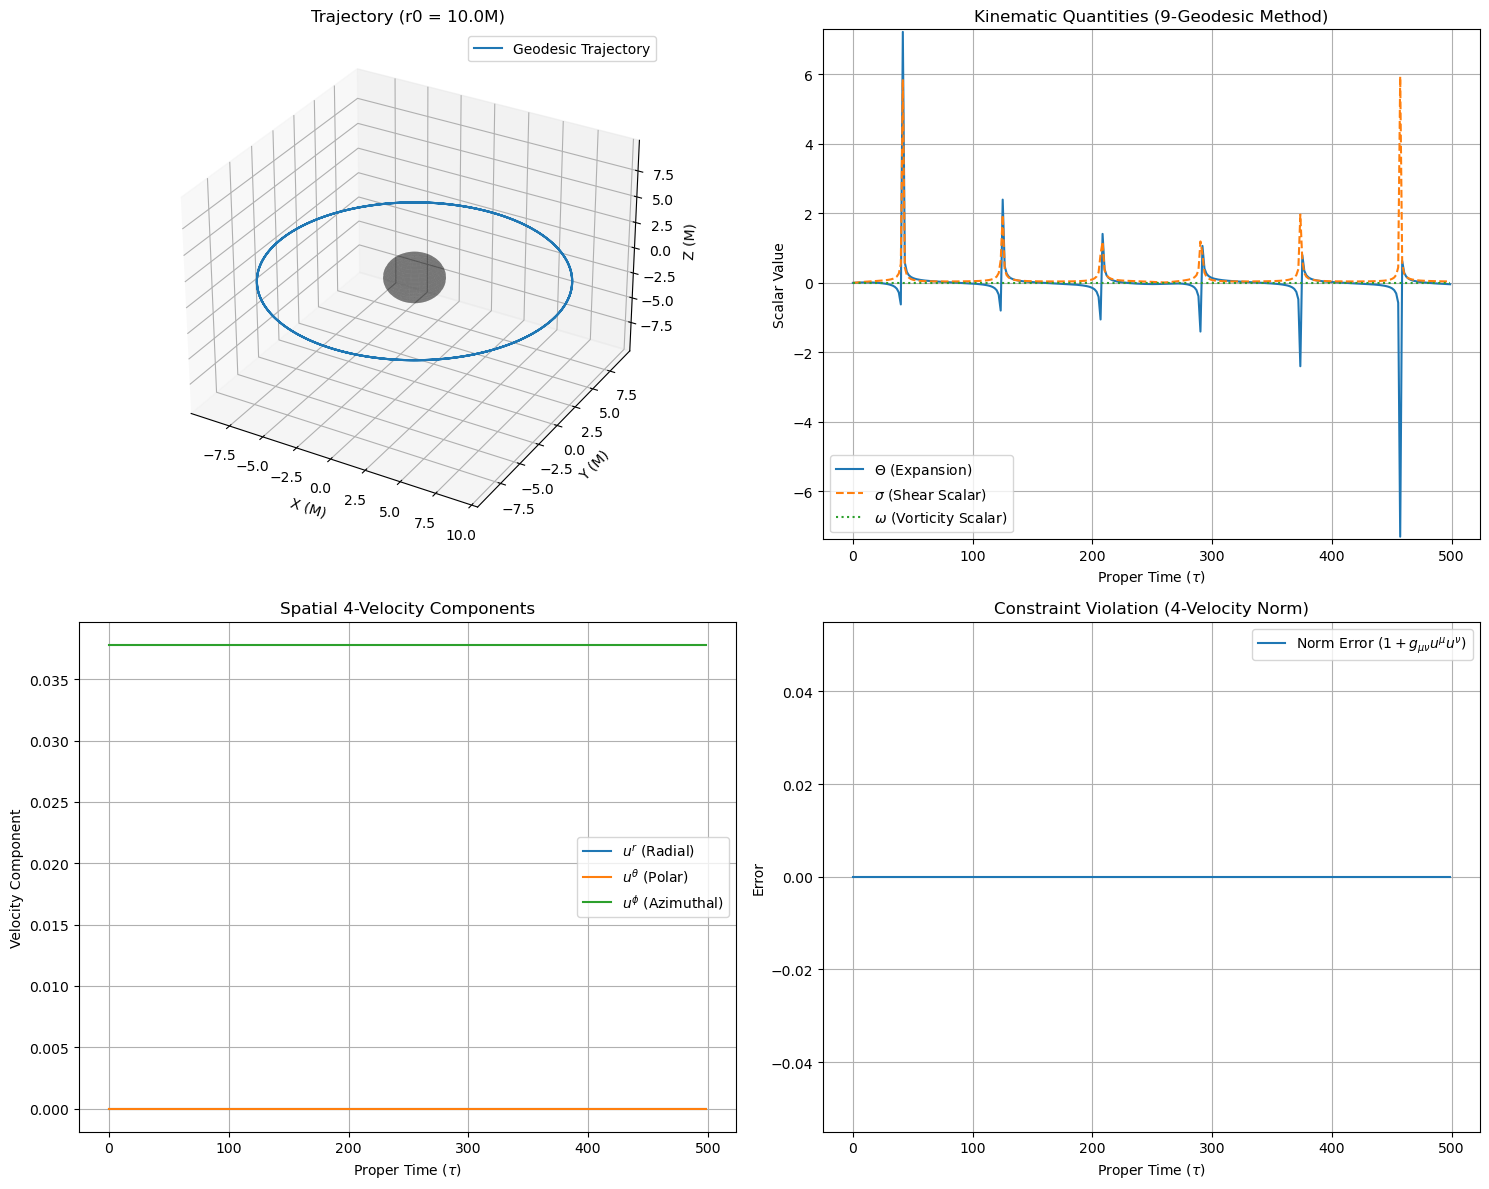

In [ ]:
# --- Example Usage (UPDATED) ---
if __name__ == "__main__":
    # --- Define Initial Conditions for Schwarzschild ---
    r0 = 10.0 * M

    # 1. Initial position
    x0 = np.array([0.0, r0, np.pi / 2.0, 0.0])

    # 2. Initial 4-velocity for a circular orbit at r0
    if r0 <= 6.0 * M:
        print(f"Warning: Initial radius r={r0}M is inside the ISCO (6M).")

    u_t_0 = np.sqrt(1.0 / (1.0 - 3.0 * M / r0))
    u_phi_0 = np.sqrt(M / r0**3) * u_t_0

    u0 = np.array([u_t_0, 0.0, 0.0, u_phi_0])

    # 3. Integration time
    Omega = u_phi_0 / u_t_0
    T_coord = 2.0 * np.pi / Omega
    T_tau = T_coord / u_t_0
    tau_end = 3.0 * T_tau  # Integrate for 3 orbits

    print(f"--- Initial Conditions (M={M}) ---")
    print(f"Coordinates: [t, r, theta, phi]")
    print(f"Initial Position x: {x0}")
    print(f"Initial 4-Velocity u: {u0}")
    print(f"Finite Difference Epsilon: {FINITE_DIFF_EPSILON}")
    print(f"Orbital Period (Proper Time): {T_tau:.2f}")
    print(f"Integrating from \tau=0 to \tau={tau_end:.2f}")

    # --- Run the simulation (Method 2) ---
    t, all_states = evolve_9_geodesics(
        x0, u0, tau_end, num_steps=300, max_step=T_tau / 100.0  # 100 steps per orbit
    )

    # --- Post-Process: Calculate Kinematics (Method 2) ---
    kinematics = calculate_kinematics_from_9_geodesics(t, all_states)

    theta_t = kinematics["theta"]
    sigma_norm_t = kinematics["sigma_norm"]
    omega_norm_t = kinematics["omega_norm"]
    norm_error_t = kinematics["norm_error"]

    print(f"\n--- Final State (at \tau = {t[-1]:.2f}) ---")
    print(f"Initial Expansion \Theta: {theta_t[0]:.2e} | Final: {theta_t[-1]:.2e}")
    print(
        f"Initial Shear \sigma:     {sigma_norm_t[0]:.2e} | Final: {sigma_norm_t[-1]:.2e}"
    )
    print(
        f"Initial Vorticity \omega: {omega_norm_t[0]:.2e} | Final: {omega_norm_t[-1]:.2e}"
    )
    print(f"Final Norm Error (1+u.u): {norm_error_t[-1]:.2e}")

    # --- Plot the results ---
    try:
        # Need to import 3D plotting capability\n",
        from mpl_toolkits.mplot3d import Axes3D
    except ImportError:
        # print(\"\\nSkipping 3D plot: mpl_toolkits.mplot3d not found.\")
        # Fallback to 2D plots only\n",
        fig, (ax2, ax4) = plt.subplots(2, 1, figsize=(8, 10))
    else:
        fig = plt.figure(figsize=(15, 12))  # Make figure larger for 4 plots

        # --- Plot 1: 3D Trajectory (Central Geodesic) ---
        ax1 = fig.add_subplot(2, 2, 1, projection="3d")
        x_t_central = all_states[0, 0, :, :]  # Get central geodesic

        r_t_plot = x_t_central[1, :]
        theta_t_plot = x_t_central[2, :]
        phi_t_plot = x_t_central[3, :]

        valid_indices = ~np.isnan(r_t_plot)
        r_t_plot, theta_t_plot, phi_t_plot = (
            r_t_plot[valid_indices],
            theta_t_plot[valid_indices],
            phi_t_plot[valid_indices],
        )

        x_cart = r_t_plot * np.sin(theta_t_plot) * np.cos(phi_t_plot)
        y_cart = r_t_plot * np.sin(theta_t_plot) * np.sin(phi_t_plot)
        z_cart = r_t_plot * np.cos(theta_t_plot)

        # Draw the black hole horizon
        u_bh, v_bh = np.mgrid[0 : 2 * np.pi : 20j, 0 : np.pi : 10j]
        x_bh = 2 * M * np.cos(u_bh) * np.sin(v_bh)
        y_bh = 2 * M * np.sin(u_bh) * np.sin(v_bh)
        z_bh = 2 * M * np.cos(v_bh)
        ax1.plot_surface(x_bh, y_bh, z_bh, color="k", alpha=0.3, rstride=1, cstride=1)

        ax1.plot(x_cart, y_cart, z_cart, label="Geodesic Trajectory")
        ax1.set_xlabel("X (M)")
        ax1.set_ylabel("Y (M)")
        ax1.set_zlabel("Z (M)")
        ax1.set_title(f"Trajectory (r0 = {r0/M:.1f}M)")
        ax1.set_box_aspect([1, 1, 1])  # Equal aspect ratio
        ax1.legend()
        
        u_bh = np.linspace(0, 2 * np.pi, 100)
        v_bh = np.linspace(0, np.pi, 100)
        R_bh = 2 * M
        x_bh = R_bh * np.outer(np.cos(u_bh), np.sin(v_bh))
        y_bh = R_bh * np.outer(np.sin(u_bh), np.sin(v_bh))
        z_bh = R_bh * np.outer(np.ones(np.size(u_bh)), np.cos(v_bh))
        ax1.plot_surface(
            x_bh,
            y_bh,
            z_bh,
            color="k",
            alpha=0.3,
            rstride=5,
            cstride=5,
            label="Horizon (2M)",
        )

        ax1.plot(x_cart, y_cart, z_cart, label="Geodesic Trajectory")
        ax1.set_xlabel("X (M)")
        ax1.set_ylabel("Y (M)")
        ax1.set_zlabel("Z (M)")
        ax1.set_title(f"Trajectory (r0 = {r0/M:.1f}M)")

        max_range = (
            np.array(
                [
                    x_cart.max() - x_cart.min(),
                    y_cart.max() - y_cart.min(),
                    z_cart.max() - z_cart.min(),
                ]
            ).max()
            / 2.0
        )
        if not np.isfinite(max_range) or max_range == 0:
            max_range = r0
        mid_x = (x_cart.max() + x_cart.min()) * 0.5
        mid_y = (y_cart.max() + y_cart.min()) * 0.5
        mid_z = (z_cart.max() + z_cart.min()) * 0.5
        ax1.set_xlim(mid_x - max_range, mid_x + max_range)
        ax1.set_ylim(mid_y - max_range, mid_y + max_range)
        ax1.set_zlim(mid_z - max_range, mid_z + max_range)
        ax1.legend()

        # --- Plot 2: Kinematics ---
        ax2 = fig.add_subplot(2, 2, 2)
        ax2.plot(t, theta_t, label=r"$\Theta$ (Expansion)")
        ax2.plot(t, sigma_norm_t, label=r"$\sigma$ (Shear Scalar)", linestyle="--")
        ax2.plot(t, omega_norm_t, label=r"$\omega$ (Vorticity Scalar)", linestyle=":")
        ax2.set_xlabel(r"Proper Time ($\tau$)")
        ax2.set_ylabel("Scalar Value")
        ax2.set_title("Kinematic Quantities (9-Geodesic Method)")
        ax2.legend()
        ax2.grid(True)

        all_kin_vals = np.concatenate(
            [
                theta_t[~np.isnan(theta_t)],
                sigma_norm_t[~np.isnan(sigma_norm_t)],
                omega_norm_t[~np.isnan(omega_norm_t)],
            ]
        )
        if all_kin_vals.size > 0:
            min_val = np.min(all_kin_vals)
            max_val = np.max(all_kin_vals)
            padding = max(0.01 * max(abs(min_val), abs(max_val)), 0.01)
            ax2.set_ylim(min_val - padding, max_val + padding)

        # --- Plot 3: Spatial Velocity Components (Central Geodesic) ---
        ax3 = fig.add_subplot(2, 2, 3)
        u_t_central = all_states[0, 1, :, :]
        ax3.plot(t, u_t_central[1, :], label=r"$u^r$ (Radial)")
        ax3.plot(t, u_t_central[2, :], label=r"$u^\theta$ (Polar)")
        ax3.plot(t, u_t_central[3, :], label=r"$u^\phi$ (Azimuthal)")
        ax3.set_xlabel(r"Proper Time ($\tau$)")
        ax3.set_ylabel("Velocity Component")
        ax3.set_title("Spatial 4-Velocity Components")
        ax3.legend()
        ax3.grid(True)

        # --- Plot 4: Error Check (Central Geodesic) ---
        ax4 = fig.add_subplot(2, 2, 4)
        ax4.plot(t, norm_error_t, label=r"Norm Error ($1 + g_{\mu\nu}u^\mu u^\nu$)")
        ax4.set_xlabel(r"Proper Time ($\tau$)")
        ax4.set_ylabel("Error")
        ax4.set_title("Constraint Violation (4-Velocity Norm)")
        ax4.legend()
        ax4.grid(True)

        plt.tight_layout()
        plt.savefig("schwarzschild_kinematics_stable_9geodesic.png")
        print(
            "\nSaved kinematics plot to 'schwarzschild_kinematics_stable_9geodesic.png'"
        )

In [48]:
if True:
    u_bh = np.linspace(0, 2 * np.pi, 100)
    v_bh = np.linspace(0, np.pi, 100)
    R_bh = 2 * M
    x_bh = R_bh * np.outer(np.cos(u_bh), np.sin(v_bh))
    y_bh = R_bh * np.outer(np.sin(u_bh), np.sin(v_bh))
    z_bh = R_bh * np.outer(np.ones(np.size(u_bh)), np.cos(v_bh))

In [59]:
u_bh.shape, v_bh.shape, x_bh.shape, y_bh.shape, z_bh.shape

((100,), (100,), (100, 100), (100, 100), (100, 100))

In [58]:
z_bh

array([[ 2.        ,  1.99899308,  1.99597335, ..., -1.99597335,
        -1.99899308, -2.        ],
       [ 2.        ,  1.99899308,  1.99597335, ..., -1.99597335,
        -1.99899308, -2.        ],
       [ 2.        ,  1.99899308,  1.99597335, ..., -1.99597335,
        -1.99899308, -2.        ],
       ...,
       [ 2.        ,  1.99899308,  1.99597335, ..., -1.99597335,
        -1.99899308, -2.        ],
       [ 2.        ,  1.99899308,  1.99597335, ..., -1.99597335,
        -1.99899308, -2.        ],
       [ 2.        ,  1.99899308,  1.99597335, ..., -1.99597335,
        -1.99899308, -2.        ]])